In [4]:
import traci # this code will determiene or give you baseline reward when no rl
import numpy as np
from datetime import datetime
import pytz

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\best-scenario\scenario\sumo\berlin.sumocfg"#begin value is 45200.for my sumo confg file

light = "green"
episode = 1
max_step = 1000

alpha = 0.05
gamma = 0.92

max_green = 30
min_green = 5
max_red = 3
n=650
e = 1
e_min = 0.005
e_decay = (0.005)**(1/n)
green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0
c=0

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

LANES_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
LANES_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
LANES_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
LANES_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']

def queueOfSubLane(subLaneNo):
    return traci.lane.getLastStepHaltingNumber(subLaneNo)
    
def queueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = queueLength(LANES_A)
    B = queueLength(LANES_B)
    C = queueLength(LANES_C)
    D = queueLength(LANES_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)

queue_history =[]
ep_history = []
reward_history = []

for ep in range(1, episode + 1):
    ep_start_time = datetime.now(pytz.timezone("Asia/Kolkata")).strftime("%Y-%m-%d %H:%M:%S")
    ep_history.append(ep)
    
    traci.start([sumo_exe,"-c", sumo_cfg,"--no-step-log","--quit-on-end"])
    
    ep_reward = 0
    total_ep_queue = 0

    for step in range(0,max_step):
        traci.simulationStep()
        state = get_state(tls_id)
        reward = get_reward(state)
        total_ep_queue += sum(state[:4])
        ep_reward += reward
        
    traci.close()
    
    reward_history.append(ep_reward)
    queue_history.append(total_ep_queue)
    
    print(f"Episode {ep:03d}/{episode} | StartTime {ep_start_time} | QueueLength {total_ep_queue} | Reward {ep_reward:12.2f}")

print("\nSimulation finished")
print(f"Total Queue: {queue_history[0]}")
print(f"Total Reward: {reward_history[0]}")

Episode 001/1 | StartTime 2026-03-12 05:38:45 | QueueLength 1684 | Reward     -3720.00

Simulation finished
Total Queue: 1684
Total Reward: -3720


Episode 001/1 | StartTime 2026-03-12 05:22:50 | QueueLength 1684 | Reward     -3720.00


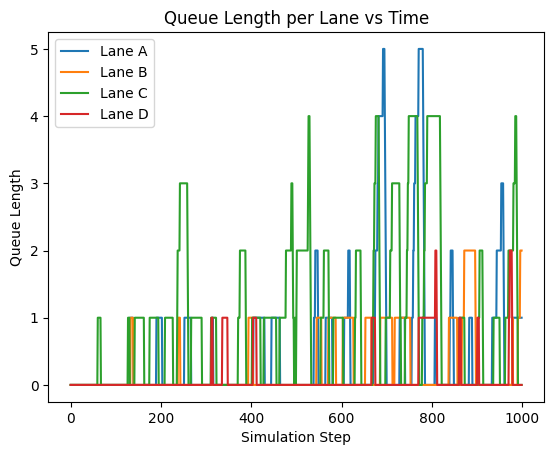


Simulation finished
Total Queue: 1684
Total Reward: -3720


In [3]:

import traci # this gives you a plot of graph of queue in each lane
import numpy as np
from datetime import datetime
import pytz
import matplotlib.pyplot as plt 

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\best-scenario\scenario\sumo\berlin.sumocfg"

light = "green"
episode = 1
max_step = 1000

alpha = 0.05
gamma = 0.92

max_green = 30
min_green = 5
max_red = 3
n=650
e = 1
e_min = 0.005
e_decay = (0.005)**(1/n)
green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0
c=0

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

LANES_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
LANES_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
LANES_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
LANES_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']

def queueOfSubLane(subLaneNo):
    return traci.lane.getLastStepHaltingNumber(subLaneNo)
    
def queueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = queueLength(LANES_A)
    B = queueLength(LANES_B)
    C = queueLength(LANES_C)
    D = queueLength(LANES_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)

queue_history =[]
ep_history = []
reward_history = []

A_hist = []
B_hist = []
C_hist = []
D_hist = []
step_hist = []
for ep in range(1, episode + 1):
   
    ep_start_time = datetime.now(pytz.timezone("Asia/Kolkata")).strftime("%Y-%m-%d %H:%M:%S")
    ep_history.append(ep)
    
    traci.start([sumo_exe,"-c", sumo_cfg,"--no-step-log","--quit-on-end"])
    
    ep_reward = 0
    total_ep_queue = 0

    for step in range(0,max_step):
        traci.simulationStep()
        state = get_state(tls_id)
        A, B, C, D, L = state

        A_hist.append(A)
        B_hist.append(B)
        C_hist.append(C)
        D_hist.append(D)
        step_hist.append(step)
        
        reward = get_reward(state)
        total_ep_queue += sum(state[:4])
        ep_reward += reward
   
        
    traci.close()
    
    reward_history.append(ep_reward)
    queue_history.append(total_ep_queue)
    
    print(f"Episode {ep:03d}/{episode} | StartTime {ep_start_time} | QueueLength {total_ep_queue} | Reward {ep_reward:12.2f}")
plt.figure()

plt.plot(step_hist, A_hist, label="Lane A")
plt.plot(step_hist, B_hist, label="Lane B")
plt.plot(step_hist, C_hist, label="Lane C")
plt.plot(step_hist, D_hist, label="Lane D")

plt.xlabel("Simulation Step")
plt.ylabel("Queue Length")
plt.title("Queue Length per Lane vs Time")
plt.legend()

plt.show()
print("\nSimulation finished")
print(f"Total Queue: {queue_history[0]}")
print(f"Total Reward: {reward_history[0]}")

Running trained RL controller...


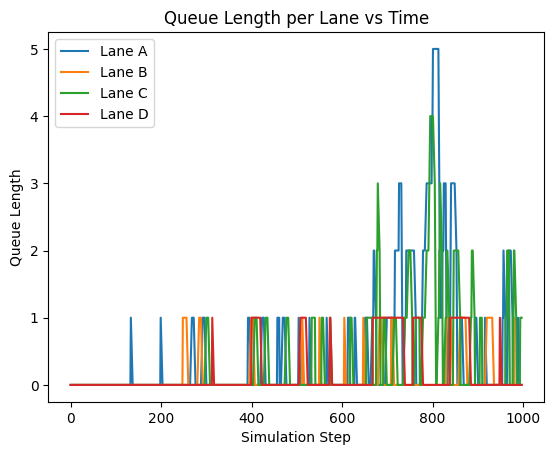


Model Evaluation Result
Total Reward: -1192
Total Queue: 638


In [1]:

# this code has some problem
import traci 
import pickle 
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from datetime import datetime
import pytz

sumo_gui = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\best-scenario\scenario\sumo\berlin.sumocfg"

Ac =[0,2,4,6]

light = "green"
episode = 700
max_step = 1000

alpha = 0.05
gamma = 0.92

max_green = 30
min_green = 5
max_red = 3
n=650
e = 1
e_min = 0.005
e_decay = (0.005)**(1/n)
green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0
c=0

with open("model_version1.pkl", "rb") as f:
    Q_loaded = pickle.load(f)
    
Q = defaultdict(lambda: np.zeros(4), Q_loaded)

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

LANES_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
LANES_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
LANES_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
LANES_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']


def queueOfSubLane(subLaneNo):
    return (traci.lane.getLastStepHaltingNumber(subLaneNo))
    
def queueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = queueLength(LANES_A)
    B = queueLength(LANES_B)
    C = queueLength(LANES_C)
    D = queueLength(LANES_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)

def e_greedy(state,e):
    if random.random()<e:
        return random.randint(0, 3)
    return int(np.argmax(Q[state]))

def NextPhase(action,phase):
    if action == 1:
        return (phase + 2) % total_ph
    elif action == 2:
        return (phase + 4) % total_ph
    elif action == 3:
        return (phase + 6) % total_ph
    return phase
    
def YPhase(phase):
    return (phase + 1) % total_ph

    
def is_G(phase):
    return phase in green_ph

def current_phase(tls_id): 
    return traci.trafficlight.getPhase(tls_id)


def mustSwitch(phase,duration):
    if (phase in green_ph and duration >= max_green):
        return True
    elif (phase in red_ph and duration >= max_red):
        return True
    return False
    
def canRLAct(phase,duration):
    if (phase in green_ph and (duration >= min_green) and (duration < max_green )):
        return True
    return False

total_reward = 0
total_ep_queue = 0
step = 0


traci.start([sumo_gui,"-c",sumo_cfg])

print("Running trained RL controller...")
step =0
A_hist = []
B_hist = []
C_hist = []
D_hist = []
step_hist = []
while step<max_step:
    state = get_state(tls_id)
    phase = current_phase(tls_id)
    duration = traci.trafficlight.getSpentDuration(tls_id)
    A, B, C, D, L = state

    A_hist.append(A)
    B_hist.append(B)
    C_hist.append(C)
    D_hist.append(D)
    step_hist.append(step)
    total_ep_queue+= A+B+C+D
    
    if state in Q:
        action = int(np.argmax(Q[state]))
    else:
        action = 0

    if(mustSwitch(phase,duration)):
        
        if phase in green_ph:
            if(action == 0 ):
                action =  1
            traci.trafficlight.setPhase(tls_id, phase+1)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                traci.simulationStep()
            step = step + 3 
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

        elif phase in red_ph:
            action = 1
            traci.trafficlight.setPhase(tls_id, phase+1)
            
        phase = current_phase(tls_id)
        duration = traci.trafficlight.getSpentDuration(tls_id)
        if(phase in green_ph):
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            
    elif(canRLAct(phase,duration)):
        if(action == 0):
            traci.trafficlight.setPhase(tls_id, phase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhase(tls_id, phase+1)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                traci.simulationStep()
            step = step + 3 
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

    traci.simulationStep()
    step += 1
    new_state = get_state(tls_id)
    reward = get_reward(new_state)
    
    total_reward += reward

traci.close()
plt.figure()

plt.plot(step_hist, A_hist, label="Lane A")
plt.plot(step_hist, B_hist, label="Lane B")
plt.plot(step_hist, C_hist, label="Lane C")
plt.plot(step_hist, D_hist, label="Lane D")

plt.xlabel("Simulation Step")
plt.ylabel("Queue Length")
plt.title("Queue Length per Lane vs Time")
plt.legend()

plt.show()

print("\nModel Evaluation Result")
print("Total Reward:", total_reward)
print("Total Queue:", total_ep_queue)


In [2]:

# this code has some problem
import traci 
import pickle 
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from datetime import datetime
import pytz

sumo_gui = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo-gui.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\best-scenario\scenario\sumo\berlin.sumocfg"

Ac =[0,2,4,6]

light = "green"
episode = 700
max_step = 1000

alpha = 0.05
gamma = 0.92

max_green = 30
min_green = 5
max_red = 3
n=650
e = 1
e_min = 0.005
e_decay = (0.005)**(1/n)
green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0
c=0

with open("model_version1.pkl", "rb") as f:
    Q_loaded = pickle.load(f)
    
Q = defaultdict(lambda: np.zeros(4), Q_loaded)

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

LANES_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
LANES_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
LANES_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
LANES_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']


def queueOfSubLane(subLaneNo):
    return (traci.lane.getLastStepHaltingNumber(subLaneNo))
    
def queueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = queueLength(LANES_A)
    B = queueLength(LANES_B)
    C = queueLength(LANES_C)
    D = queueLength(LANES_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)

def e_greedy(state,e):
    if random.random()<e:
        return random.randint(0, 3)
    return int(np.argmax(Q[state]))

def NextPhase(action,phase):
    if action == 1:
        return (phase + 2) % total_ph
    elif action == 2:
        return (phase + 4) % total_ph
    elif action == 3:
        return (phase + 6) % total_ph
    return phase
    
def YPhase(phase):
    return (phase + 1) % total_ph

    
def is_G(phase):
    return phase in green_ph

def current_phase(tls_id): 
    return traci.trafficlight.getPhase(tls_id)


def mustSwitch(phase,duration):
    if (phase in green_ph and duration >= max_green):
        return True
    elif (phase in red_ph and duration >= max_red):
        return True
    return False
    
def canRLAct(phase,duration):
    if (phase in green_ph and (duration >= min_green) and (duration < max_green )):
        return True
    return False

total_reward = 0
total_queue = 0
step = 0


traci.start([sumo_gui,"-c",sumo_cfg])

print("Running trained RL controller...")
step =0
while step<max_step:
    state = get_state(tls_id)
    phase = current_phase(tls_id)
    duration = traci.trafficlight.getSpentDuration(tls_id)
    total_queue+= sum(state[:4])
    if state in Q:
        action = int(np.argmax(Q[state]))
    else:
        action = 0

    if(mustSwitch(phase,duration)):
        
        if phase in green_ph:
            if(action == 0 ):
                action =  1
            traci.trafficlight.setPhase(tls_id, phase+1)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                traci.simulationStep()
            step = step + 3 
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

        elif phase in red_ph:
            action = 1
            traci.trafficlight.setPhase(tls_id, phase+1)
            
        phase = current_phase(tls_id)
        duration = traci.trafficlight.getSpentDuration(tls_id)
        if(phase in green_ph):
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            
    elif(canRLAct(phase,duration)):
        if(action == 0):
            traci.trafficlight.setPhase(tls_id, phase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhase(tls_id, phase+1)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                traci.simulationStep()
            step = step + 3 
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

    traci.simulationStep()
    step += 1
    new_state = get_state(tls_id)
    reward = get_reward(new_state)
    
    total_reward += reward

traci.close()

print("\nModel Evaluation Result")
print("Total Reward:", total_reward)
print("Total Queue:", total_queue)


Running trained RL controller...

Model Evaluation Result
Total Reward: -1192
Total Queue: 638
